# Analyse af afledte allel counts i Baboon data


Denne notebook viser, hvordan man:

1. Loader genomdata med sgkit
2. Filtrerer et subset af samples
3. Beregner derived allele counts (singletons, doubletons, osv.)
4. Visualiserer og analyserer resultaterne

Datasættet er fra baboon diversity projektet (kromosom 20).

In [1]:
import pandas as pd
import sgkit as sg
import numpy as np
import matplotlib.pyplot as plt

## Load datasæt

Jeg loader Zarr-datasættet for kromosom 20.

In [2]:
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")
ds

<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_id             (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                    ...
    variant_filter        (variants, filters) bool 3MB dask.array<chunksize=(1000, 1), meta=np.ndarray>
    variant_id            (variants) object 21MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_id_mask       (variants) bool 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_length        (variants) int8 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_position      (variants) int32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_quality       (variants) float32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    source:                bio2zarr-0.1.7
    vcf_meta_information:  [['fileformat', 'VCFv4.2'], ['fileDate', '06/07/20...
    vcf_zarr_version:      0.4

## Beregn variant allele counts

In [3]:
variant_allele_counts = sg.count_variant_alleles(ds)

# variant_allele_count has shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   # triggers compute
nr_samples = ac.sum(axis=1)              # nr haploid samples (chromosomes)

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


Hvilke samples der findes

In [4]:
ds['sample_id'].values

array(['Sci_16066', 'Sci_16098', 'Sci_30877', 'Sci_30977', 'Sci_34449',
       'Sci_34474', 'Sci_38168', 'Sci_97074', 'Sci_97124', 'PD_0067',
       'PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0204',
       'PD_0205', 'PD_0206', 'PD_0207', 'PD_0208', 'PD_0209', 'PD_0210',
       'PD_0211', 'PD_0212', 'PD_0213', 'PD_0214', 'PD_0215', 'PD_0216',
       'PD_0217', 'PD_0218', 'PD_0219', 'PD_0220', 'PD_0221', 'PD_0222',
       'PD_0223', 'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228',
       'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234',
       'PD_0235', 'PD_0236', 'PD_0237', 'PD_0238', 'PD_0239', 'PD_0240',
       'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
       'PD_0267', 'PD_0268', 'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272',
       'PD_0390', 'PD_0391', 'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395',
       'PD_0396', 'PD_0397', 'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401',
       'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_

## Udvælg et subset af samples

Her vælger jeg specifikke individer.

In [5]:
keep = ['PD_0205', 'PD_0212', 'PD_0715', 'PD_0792', 'PD_0689', 'PD_0492']
mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)

## Beregn variant allele counts

Jeg beregner antal alleler pr. variant.

In [20]:
variant_allele_counts = sg.count_variant_alleles(ds_sub)

ac = variant_allele_counts["variant_allele_count"].values
nr_samples = ac.sum(axis=1)

Opret DataFrame med derived allele counts

In [6]:
derived_variant_count_df = pd.DataFrame({
    "position": ds_sub["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})

derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


## Fordeling af derived allele counts

In [7]:
derived_variant_count_df["derived_count"].value_counts().sort_index()

derived_count
1      411797
2      249479
3      180875
4      376239
5      103960
        ...  
450       599
451       526
452       584
453       629
454      5806
Name: count, Length: 454, dtype: int64

## Histogram af derived allele counts

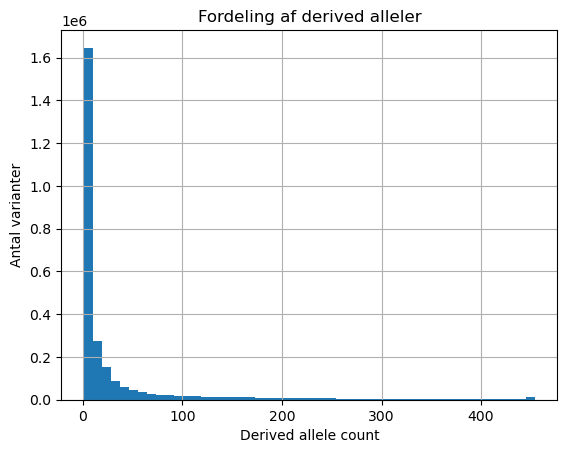

In [8]:
plt.figure()
derived_variant_count_df["derived_count"].hist(bins=50)
plt.xlabel("Derived allele count")
plt.ylabel("Antal varianter")
plt.title("Fordeling af derived alleler")
plt.show()

Frekvens (allele frequency)

In [9]:
derived_variant_count_df["frequency"] = (
    derived_variant_count_df["derived_count"] /
    derived_variant_count_df["nr_samples"]
)

Filtrer sjældne varianter

In [10]:
rare = derived_variant_count_df[derived_variant_count_df["derived_count"] <= 2]
rare.head()

,position,derived_count,nr_samples,frequency
2,126,1,454,0.002203
3,148,1,454,0.002203
11,484,1,454,0.002203
12,485,1,454,0.002203
15,504,1,454,0.002203


Plot frekvens

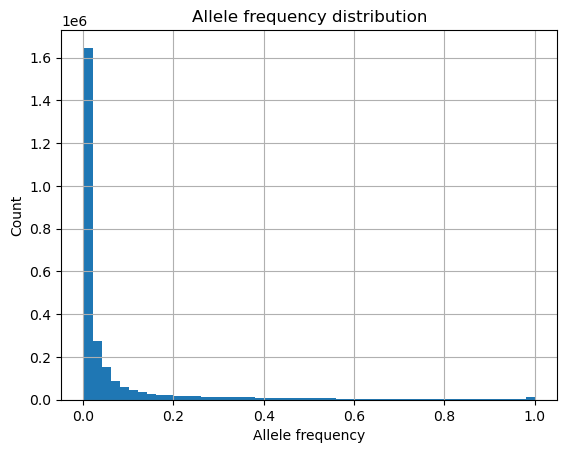

In [11]:
plt.figure()
derived_variant_count_df["frequency"].hist(bins=50)
plt.xlabel("Allele frequency")
plt.ylabel("Count")
plt.title("Allele frequency distribution")
plt.show()